# 05 Result Analysis

Local notebook for post-training metrics/table/figure analysis.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
OUT_CANDIDATES = [
    Path.cwd().resolve() / 'outputs' / 'vn30f1m_outputs_version1',
    Path.cwd().resolve().parent / 'outputs' / 'vn30f1m_outputs_version1',
    Path(r"C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1"),
]
for _candidate in OUT_CANDIDATES:
    if _candidate.exists():
        OUT = _candidate
        break
else:
    OUT = OUT_CANDIDATES[-1]
print('OUT:', OUT)

OUT: C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1


In [2]:
model_cmp = pd.read_csv(OUT / 'tables' / 'model_comparison_metrics.csv')
trade_stats = pd.read_csv(OUT / 'tables' / 'trade_statistics.csv')
wf = pd.read_csv(OUT / 'tables' / 'walk_forward_results.csv')

display(model_cmp.sort_values('sharpe_ratio', ascending=False))
display(trade_stats)
display(wf.head())

,model,total_return,sharpe_ratio,max_drawdown,profit_factor
0,decoder_tft,3.311699,2.492199,-0.343929,1.124272
1,lstm_dmn,0.251435,1.659848,-0.091217,0.943411
2,macd_32_96,1.340273,1.405880,-0.688318,0.558220
3,ema_cross_32_96,1.340273,1.405880,-0.688318,0.558220
4,decoder_transformer,0.243063,0.666332,-0.447765,0.946908
5,ema_cross_8_24,-0.884802,-0.253623,-0.974891,0.207407
6,macd_8_24,-0.884802,-0.253623,-0.974891,0.207407
7,tsmom_78,-0.968105,-0.940539,-0.980262,0.231975
8,macd_16_48,-0.971823,-0.998027,-0.977679,0.339543
9,ema_cross_16_48,-0.971823,-0.998027,-0.977679,0.339543


,model,number_of_trades,turnover,average_net_pnl_points,percentage_time_long,percentage_time_short,percentage_time_flat
0,decoder_tft,13575,17326.0,0.040032,0.273282,0.352387,0.374331
1,decoder_transformer,18235,23510.0,0.006973,0.332227,0.247536,0.420236
2,ema_cross_16_48,4450,22250.0,-0.034670,0.499491,0.436544,0.063964
3,ema_cross_32_96,3372,16860.0,0.067165,0.533208,0.415901,0.050891
4,ema_cross_8_24,6438,32190.0,-0.001923,0.476647,0.438912,0.084441
5,long_only,2400,12000.0,-0.071257,0.959647,0.000000,0.040353
6,lstm_dmn,1440,1550.0,0.005182,0.113955,0.003585,0.882460
7,macd_16_48,4450,22250.0,-0.034670,0.499491,0.436544,0.063964
8,macd_32_96,3372,16860.0,0.067165,0.533208,0.415901,0.050891
9,macd_8_24,6438,32190.0,-0.001923,0.476647,0.438912,0.084441


,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,hit_rate,profit_factor,average_trade_pnl,average_win,average_loss,win_loss_ratio,number_of_trades,turnover,window,model
0,-0.557196,-0.997614,1.837373,-3.286194,-3.810076,-0.639804,-1.559250,0.464640,0.665462,-1.187947,10.161176,-4.627075,2.196026,258,1290.0,wf_1_2021-07-01_2021-12-31,long_only
1,-0.406620,-0.967431,1.755614,-1.950480,-2.795663,-0.542804,-1.782284,0.390199,0.130696,-4.155160,7.262246,-5.229740,1.388644,1488,7440.0,wf_1_2021-07-01_2021-12-31,tsmom_12
2,-0.345701,-0.911292,1.797221,-1.347835,-1.910806,-0.619946,-1.469954,0.403226,0.145302,-4.033979,7.369142,-5.204075,1.416033,1182,5910.0,wf_1_2021-07-01_2021-12-31,tsmom_24
3,-0.116998,0.504020,1.787699,0.228306,0.317840,-0.363027,1.388380,0.428195,0.231937,-3.823073,10.005476,-5.626797,1.778183,754,3770.0,wf_1_2021-07-01_2021-12-31,tsmom_48
4,-0.300206,-0.825369,1.818445,-0.959641,-1.313443,-0.423531,-1.948779,0.443703,0.240081,-3.535520,8.909841,-5.319355,1.674985,686,3430.0,wf_1_2021-07-01_2021-12-31,tsmom_78


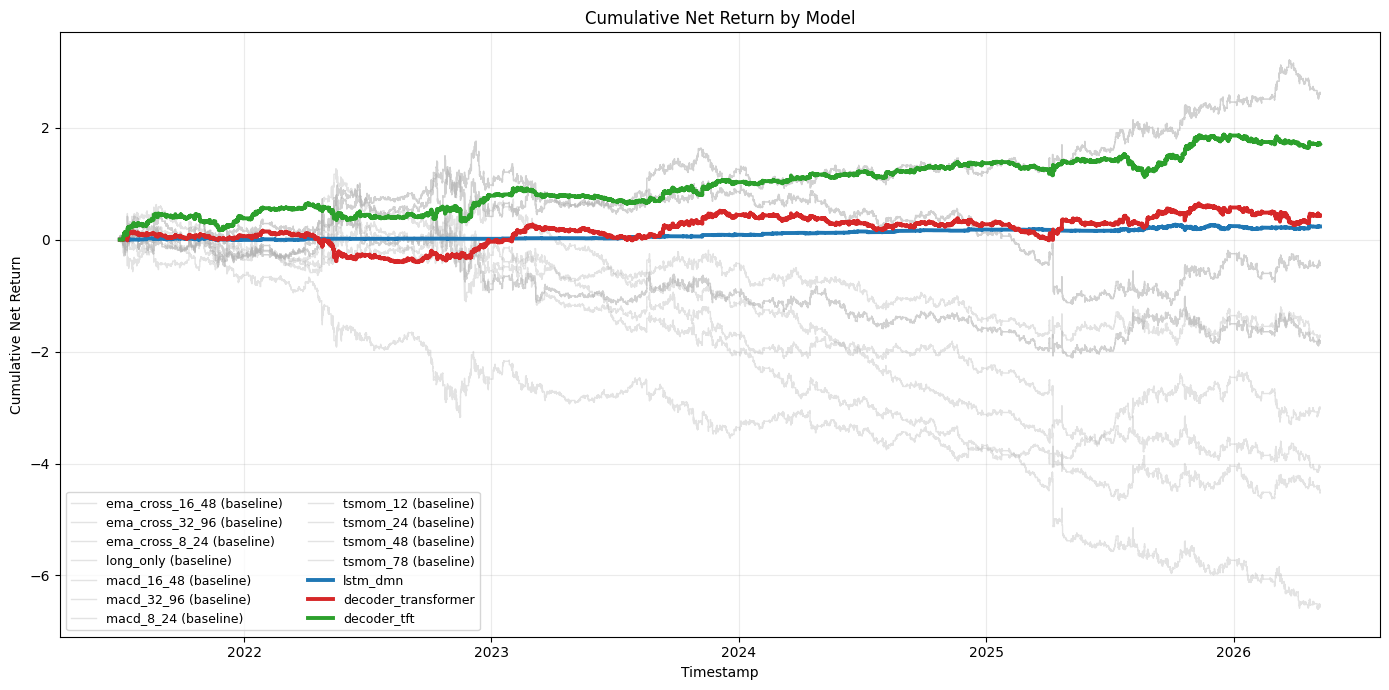

In [3]:
pred = pd.read_csv(OUT / 'predictions' / 'all_predictions.csv', parse_dates=['timestamp'])
pred = pred.sort_values(['model', 'timestamp'])
pred['cum_net_return'] = pred.groupby('model')['net_return'].cumsum()

focus_models = ['lstm_dmn', 'decoder_transformer', 'decoder_tft']
focus_colors = {
    'lstm_dmn': '#1f77b4',            # blue
    'decoder_transformer': '#d62728', # red
    'decoder_tft': '#2ca02c',         # green
}

plt.figure(figsize=(14, 7))

# plot non-focus first (background)
for model_name, g in pred.groupby('model'):
    if model_name in focus_models:
        continue
    plt.plot(
        g['timestamp'], g['cum_net_return'],
        color='#B0B0B0', linewidth=1.0, alpha=0.35,
        label=f'{model_name} (baseline)'
    )

# plot focus on top
for model_name in focus_models:
    g = pred[pred['model'] == model_name]
    if g.empty:
        continue
    plt.plot(
        g['timestamp'], g['cum_net_return'],
        color=focus_colors.get(model_name, None),
        linewidth=2.8, alpha=1.0,
        label=model_name
    )

plt.title('Cumulative Net Return by Model')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net Return')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

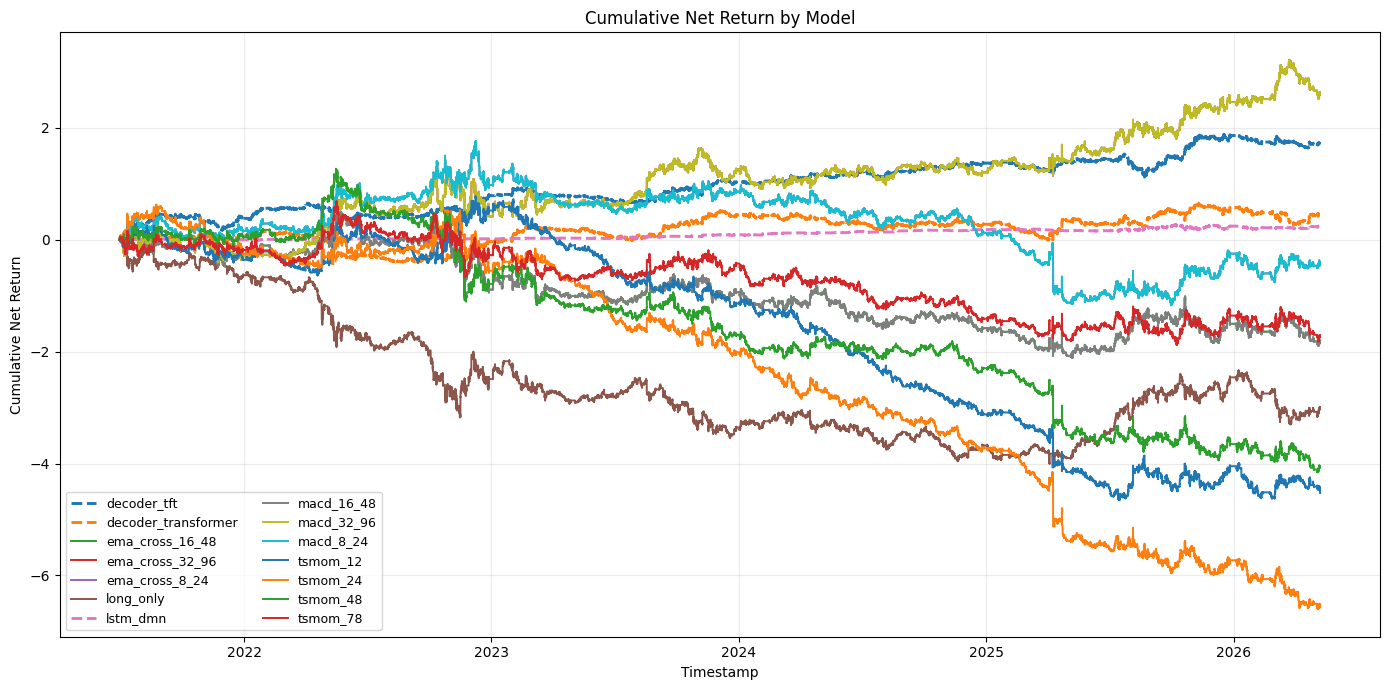

In [4]:
pred = pd.read_csv(OUT / 'predictions' / 'all_predictions.csv', parse_dates=['timestamp'])
pred = pred.sort_values(['model', 'timestamp'])
pred['cum_net_return'] = pred.groupby('model')['net_return'].cumsum()

focus_models = {'lstm_dmn', 'decoder_transformer', 'decoder_tft'}

plt.figure(figsize=(14, 7))
for model_name, g in pred.groupby('model'):
    ls = '--' if model_name in focus_models else '-'
    lw = 2.1 if model_name in focus_models else 1.4
    plt.plot(g['timestamp'], g['cum_net_return'], label=model_name, linewidth=lw, linestyle=ls)
plt.title('Cumulative Net Return by Model')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net Return')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

,days,mean_daily_cost,median_daily_cost,p95_daily_cost,max_daily_cost,total_cost
model,,,,,,
tsmom_12,1200,950024.575783,931211.930,1.575990e+06,2221515.520,1.140029e+09
tsmom_24,1200,727049.013600,667688.360,1.443859e+06,2366793.060,8.724588e+08
tsmom_48,1200,469170.038650,331816.000,1.214284e+06,2507434.280,5.630040e+08
macd_8_24,1200,449835.788950,395461.120,8.491561e+05,1396754.240,5.398029e+08
ema_cross_8_24,1200,449835.788950,395461.120,8.491561e+05,1396754.240,5.398029e+08
tsmom_78,1200,406958.103250,311578.090,1.046002e+06,1870689.040,4.883497e+08
decoder_transformer,1200,326931.285923,329999.334,5.401125e+05,955431.736,3.923175e+08
macd_16_48,1200,310695.982083,306080.290,6.700245e+05,1155650.300,3.728352e+08
ema_cross_16_48,1200,310695.982083,306080.290,6.700245e+05,1155650.300,3.728352e+08


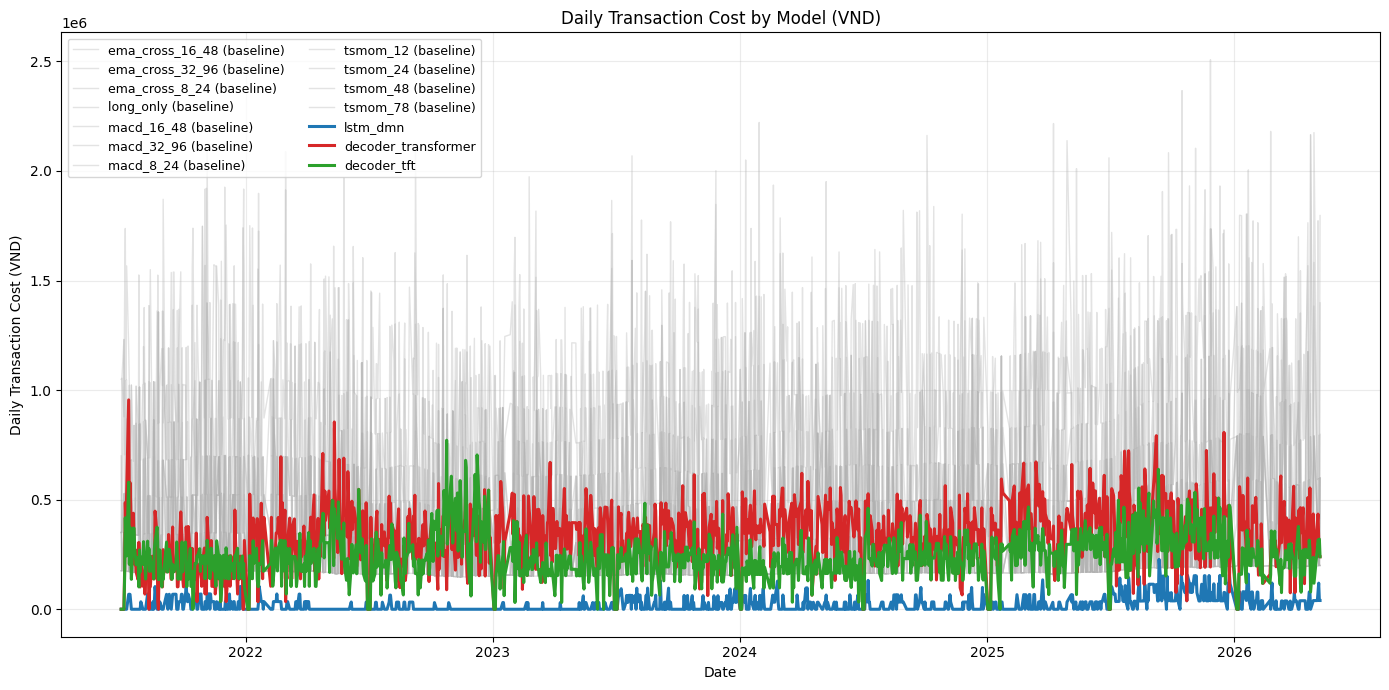

In [5]:
import numpy as np
from pathlib import Path

if 'PROJ' not in globals():
    if 'OUT' in globals():
        PROJ = OUT.parents[1]
    else:
        PROJ = Path.cwd().resolve().parent

px = pd.read_parquet(PROJ / 'data' / 'features' / 'features_5min.parquet')[['timestamp', 'close']]
cost_df = pred[['timestamp', 'model', 'position']].merge(px, on='timestamp', how='left')
cost_df = cost_df.sort_values(['model', 'timestamp']).copy()

contract_multiplier = 100000
margin_rate = 0.1848
transfer_tax_rate = 0.001
fixed_fee_per_side = 5000 + 2700 + 2700

cost_df['prev_pos'] = cost_df.groupby('model')['position'].shift(1).fillna(0.0)
cost_df['buy_units'] = (cost_df['position'] - cost_df['prev_pos']).clip(lower=0.0)
cost_df['sell_units'] = (cost_df['prev_pos'] - cost_df['position']).clip(lower=0.0)

cost_df['tax_vnd_per_contract'] = (
    margin_rate * contract_multiplier * transfer_tax_rate * cost_df['close'] / 2.0
)
cost_df['buy_cost_vnd'] = cost_df['buy_units'] * fixed_fee_per_side
cost_df['sell_fixed_cost_vnd'] = cost_df['sell_units'] * fixed_fee_per_side
cost_df['sell_tax_cost_vnd'] = cost_df['sell_units'] * cost_df['tax_vnd_per_contract']
cost_df['tx_cost_vnd'] = cost_df['buy_cost_vnd'] + cost_df['sell_fixed_cost_vnd'] + cost_df['sell_tax_cost_vnd']
cost_df['date'] = cost_df['timestamp'].dt.date

daily_cost = cost_df.groupby(['model', 'date'], as_index=False)['tx_cost_vnd'].sum()
daily_cost_stats = (
    daily_cost.groupby('model')['tx_cost_vnd']
    .agg(
        days='count',
        mean_daily_cost='mean',
        median_daily_cost='median',
        p95_daily_cost=lambda s: s.quantile(0.95),
        max_daily_cost='max',
        total_cost='sum',
    )
    .sort_values('total_cost', ascending=False)
)

display(daily_cost_stats)

focus_models = ['lstm_dmn', 'decoder_transformer', 'decoder_tft']
focus_colors = {
    'lstm_dmn': '#1f77b4',
    'decoder_transformer': '#d62728',
    'decoder_tft': '#2ca02c',
}

daily_cost = daily_cost.sort_values(['model', 'date'])
daily_cost['date'] = pd.to_datetime(daily_cost['date'])

plt.figure(figsize=(14, 7))
for model_name, g in daily_cost.groupby('model'):
    if model_name in focus_models:
        continue
    plt.plot(
        g['date'], g['tx_cost_vnd'],
        color='#B0B0B0', linewidth=1.0, alpha=0.35,
        label=f'{model_name} (baseline)'
    )

for model_name in focus_models:
    g = daily_cost[daily_cost['model'] == model_name]
    if g.empty:
        continue
    plt.plot(
        g['date'], g['tx_cost_vnd'],
        color=focus_colors.get(model_name, None),
        linewidth=2.2, alpha=1.0,
        label=model_name
    )

plt.title('Daily Transaction Cost by Model (VND)')
plt.xlabel('Date')
plt.ylabel('Daily Transaction Cost (VND)')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


In [6]:
fig_path = OUT / 'figures' / 'model_cumulative_returns.png'
print('Saved figure exists:', fig_path.exists(), fig_path)

Saved figure exists: True C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1\figures\model_cumulative_returns.png


In [7]:
import numpy as np

pred_path = OUT / 'predictions' / 'all_predictions.csv'
daily_out_path = OUT / 'tables' / 'daily_metrics_summary.csv'

pred = pd.read_csv(pred_path, parse_dates=['timestamp'])
pred['date'] = pred['timestamp'].dt.normalize()

daily_returns = (
    pred.groupby(['model', 'date'], as_index=False)['net_return']
        .sum()
        .sort_values(['model', 'date'])
)

rows = []
for model_name, g in daily_returns.groupby('model'):
    r = g['net_return'].astype(float)
    n_days = len(r)
    if n_days == 0:
        continue

    total_return = float((1.0 + r).prod() - 1.0)
    annualized_return = float((1.0 + total_return) ** (252.0 / n_days) - 1.0) if total_return > -1.0 else np.nan
    vol = float(r.std(ddof=1)) if n_days > 1 else np.nan
    annualized_volatility = float(vol * np.sqrt(252.0)) if pd.notna(vol) else np.nan
    sharpe_ratio = float((r.mean() / vol) * np.sqrt(252.0)) if pd.notna(vol) and vol > 0 else np.nan
    downside = r[r < 0].std(ddof=1)
    sortino_ratio = float((r.mean() / downside) * np.sqrt(252.0)) if pd.notna(downside) and downside > 0 else np.nan

    equity = (1.0 + r).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    max_drawdown = float(drawdown.min())
    calmar_ratio = float(annualized_return / abs(max_drawdown)) if pd.notna(annualized_return) and pd.notna(max_drawdown) and max_drawdown < 0 else np.nan

    rows.append({
        'model': model_name,
        'n_days': int(n_days),
        'total_return': total_return,
        'annualized_return': annualized_return,
        'annualized_volatility': annualized_volatility,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        'positive_day_rate': float((r > 0).mean()),
        'average_daily_return': float(r.mean()),
        'best_day_return': float(r.max()),
        'worst_day_return': float(r.min()),
    })

daily_summary = pd.DataFrame(rows).sort_values(['sharpe_ratio', 'annualized_return'], ascending=[False, False])
daily_summary.to_csv(daily_out_path, index=False)
print('Saved:', daily_out_path)
daily_summary


Saved: C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1\tables\daily_metrics_summary.csv


,model,n_days,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,positive_day_rate,average_daily_return,best_day_return,worst_day_return
0,decoder_tft,1200,3.106521,0.345332,0.347086,1.027802,1.556041,-0.315504,1.094542,0.455833,0.001416,0.146951,-0.186077
6,lstm_dmn,1200,0.248964,0.047793,0.071488,0.688803,0.574986,-0.084371,0.566466,0.205833,0.000195,0.046577,-0.045826
3,ema_cross_32_96,1200,0.911948,0.145803,0.906633,0.604736,0.871409,-0.729478,0.199873,0.489167,0.002176,0.343467,-0.365287
8,macd_32_96,1200,0.911948,0.145803,0.906633,0.604736,0.871409,-0.729478,0.199873,0.489167,0.002176,0.343467,-0.365287
1,decoder_transformer,1200,0.171996,0.033890,0.340507,0.266123,0.444609,-0.447160,0.075790,0.400833,0.000360,0.154852,-0.135545
4,ema_cross_8_24,1200,-0.970928,-0.524303,0.984307,-0.098722,-0.125736,-0.992207,-0.528420,0.470833,-0.000386,0.332930,-0.869829
9,macd_8_24,1200,-0.970928,-0.524303,0.984307,-0.098722,-0.125736,-0.992207,-0.528420,0.470833,-0.000386,0.332930,-0.869829
13,tsmom_78,1200,-0.974600,-0.537605,0.903394,-0.401215,-0.605966,-0.982708,-0.547064,0.445000,-0.001438,0.304112,-0.263496
2,ema_cross_16_48,1200,-0.978928,-0.555392,0.918866,-0.420028,-0.625468,-0.981314,-0.565968,0.445000,-0.001532,0.332930,-0.318151
7,macd_16_48,1200,-0.978928,-0.555392,0.918866,-0.420028,-0.625468,-0.981314,-0.565968,0.445000,-0.001532,0.332930,-0.318151


In [8]:
import subprocess
import sys
from pathlib import Path

RUN_LABEL = 'vn30f1m_outputs_version1'
PROJECT_ROOT = Path.cwd().resolve().parent
cmd = [
    sys.executable,
    str(PROJECT_ROOT / 'generate_daily_transactions_last_10_days.py'),
    '--run-label', RUN_LABEL,
    '--model', 'decoder_tft',
    '--num-days', '10',
]
print('Running:', ' '.join(cmd))
subprocess.run(cmd, check=True)
print('Saved:', PROJECT_ROOT / 'outputs' / RUN_LABEL / 'tables' / 'daily_transactions_last_10_days.csv')
print('Saved:', PROJECT_ROOT / 'outputs' / RUN_LABEL / 'tables' / 'daily_transaction_summary_last_10_days.csv')


Running: c:\Users\votranhuonggiang\AppData\Local\Programs\Python\Python311\python.exe C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\generate_daily_transactions_last_10_days.py --run-label vn30f1m_outputs_version1 --model decoder_tft --num-days 10
Saved: C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1\tables\daily_transactions_last_10_days.csv
Saved: C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1\tables\daily_transaction_summary_last_10_days.csv
